In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

In [3]:
## ===============================================
## CARGA Y LIMPIEZA DE DATOS
## ===============================================

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print("Forma del dataset:", X.shape)
print("Cantidad de muestras:", X.shape[0])
print("Cantidad de características:", X.shape[1], end="\n\n")

print("Características:", cancer.feature_names, end="\n\n")
print("Etiquetas:", cancer.target_names, end="\n\n")

# Manejo de valores faltantes
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

unique, counts = np.unique(y, return_counts=True)
for label, count in zip(cancer.target_names, counts):
    print(f"{label}: {count}")

Forma del dataset: (569, 30)
Cantidad de muestras: 569
Cantidad de características: 30

Características: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Etiquetas: ['malignant' 'benign']

malignant: 212
benign: 357


In [4]:
## ===============================================
## PREPROCESAMIENTO DE DATOS
## ===============================================
# Separar en conjunto de entrenamiento y prueba (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (398, 30)
Tamaño de X_test: (171, 30)
Tamaño de y_train: (398,)
Tamaño de y_test: (171,)


In [5]:
## ===============================================
## IMPLEMENTACION DE DMIN
## ===============================================
class DMINClassifier:
    def __init__(self):
        self.centroids = []
        self.classes = []

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.centroids = [np.mean(X[y == cls], axis=0) for cls in self.classes]

    def predict(self, X):
        return [self.classes[np.argmin([np.linalg.norm(x - centroid) for centroid in self.centroids])] for x in X]

In [6]:
## ===============================================
## ENTRENAMIENTO DE MODELOS
## ===============================================
# Entrenar modelos KNN
k_values = [1, 3, 5, 7, 9]
knn_accuracies = []
knn_models = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train[:, :2], y_train)  # Usar solo 2D para entrenamiento
    y_pred = knn.predict(X_test[:, :2])
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    knn_models.append(knn)

# Entrenar DMIN
dmin = DMINClassifier()
dmin.fit(X_train[:, :2], y_train)
y_pred_dmin = dmin.predict(X_test[:, :2])
acc_dmin = accuracy_score(y_test, y_pred_dmin)

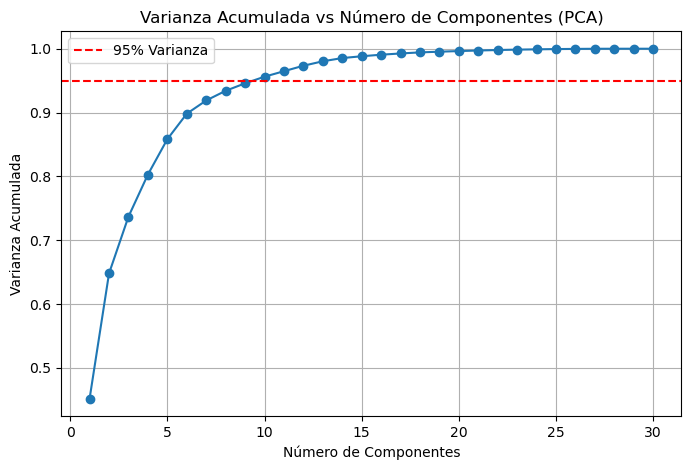

Número de componentes originales: 30
Número de componentes después de PCA: 10


In [7]:
## ===============================================
## REDUCCIÓN DE DIMENSIONALIDAD
## ===============================================
# Aplicar PCA para mantener el 95% de la varianza
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Graficar la varianza acumulada
plt.figure(figsize=(8, 5))
cum_var = np.cumsum(PCA().fit(X_train_scaled).explained_variance_ratio_)
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada vs Número de Componentes (PCA)')
plt.legend()
plt.grid(True)
plt.show()

print("Número de componentes originales:", X_train_scaled.shape[1])
print("Número de componentes después de PCA:", X_train_pca.shape[1])

In [8]:
# Entrenar KNN y DMIN con PCA
knn_pca_accuracies = []
knn_pca_models = []
for k in k_values:
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca, y_train)
    y_pred_pca = knn_pca.predict(X_test_pca)
    acc_pca = accuracy_score(y_test, y_pred_pca)
    knn_pca_accuracies.append(acc_pca)
    knn_pca_models.append(knn_pca)

# Entrenar DMIN con PCA
dmin_pca = DMINClassifier()
dmin_pca.fit(X_train_pca, y_train)
y_pred_dmin_pca = dmin_pca.predict(X_test_pca)
acc_dmin_pca = accuracy_score(y_test, y_pred_dmin_pca)

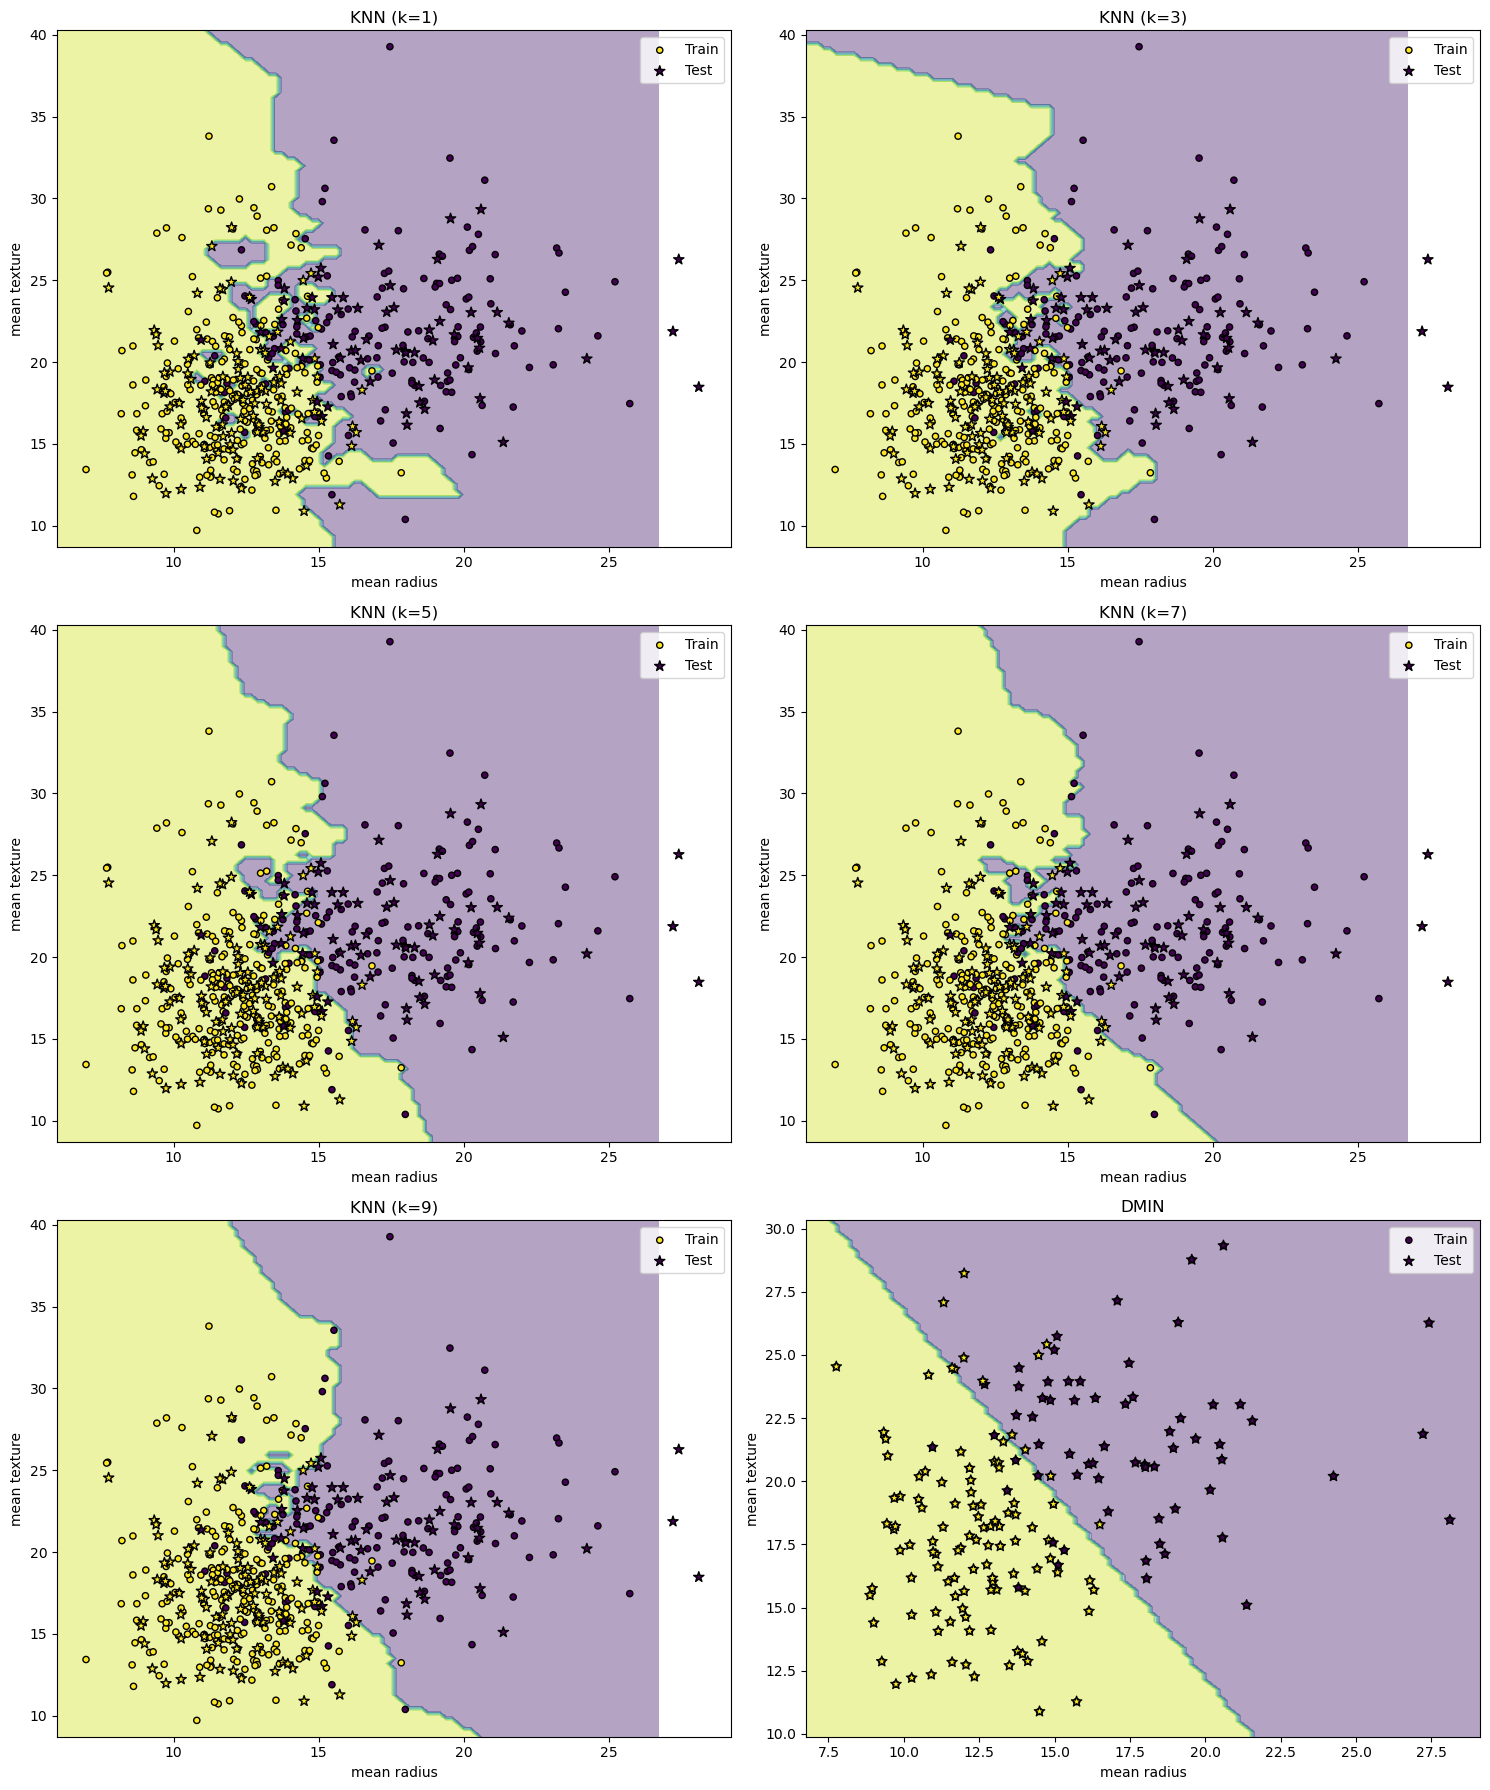

In [9]:
def plot_decision_boundaries(model, X, y, title, ax, X_test=None, y_test=None):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    if isinstance(model, KNeighborsClassifier):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        Z = np.array(model.predict(np.c_[xx.ravel(), yy.ravel()]))

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', label='Train')
    if X_test is not None and y_test is not None:
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=60, marker='*', edgecolor='k', label='Test')
    ax.set_title(title)
    ax.legend()

# Visualización de fronteras de decisión para cada modelo KNN, incluyendo test
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()
for idx, model in enumerate(knn_models):
    plot_decision_boundaries(
        model,
        X_train[:, :2],
        y_train,
        f"KNN (k={k_values[idx]})",
        axes[idx],
        X_test=X_test[:, :2],
        y_test=y_test
    )
    axes[idx].set_xlabel(cancer.feature_names[0])
    axes[idx].set_ylabel(cancer.feature_names[1])

plot_decision_boundaries(dmin, X_test[:, :2], y_test, 'DMIN', axes[5], X_test=X_test[:, :2], y_test=y_test)
axes[5].set_xlabel(cancer.feature_names[0])
axes[5].set_ylabel(cancer.feature_names[1])

plt.tight_layout()
plt.show()


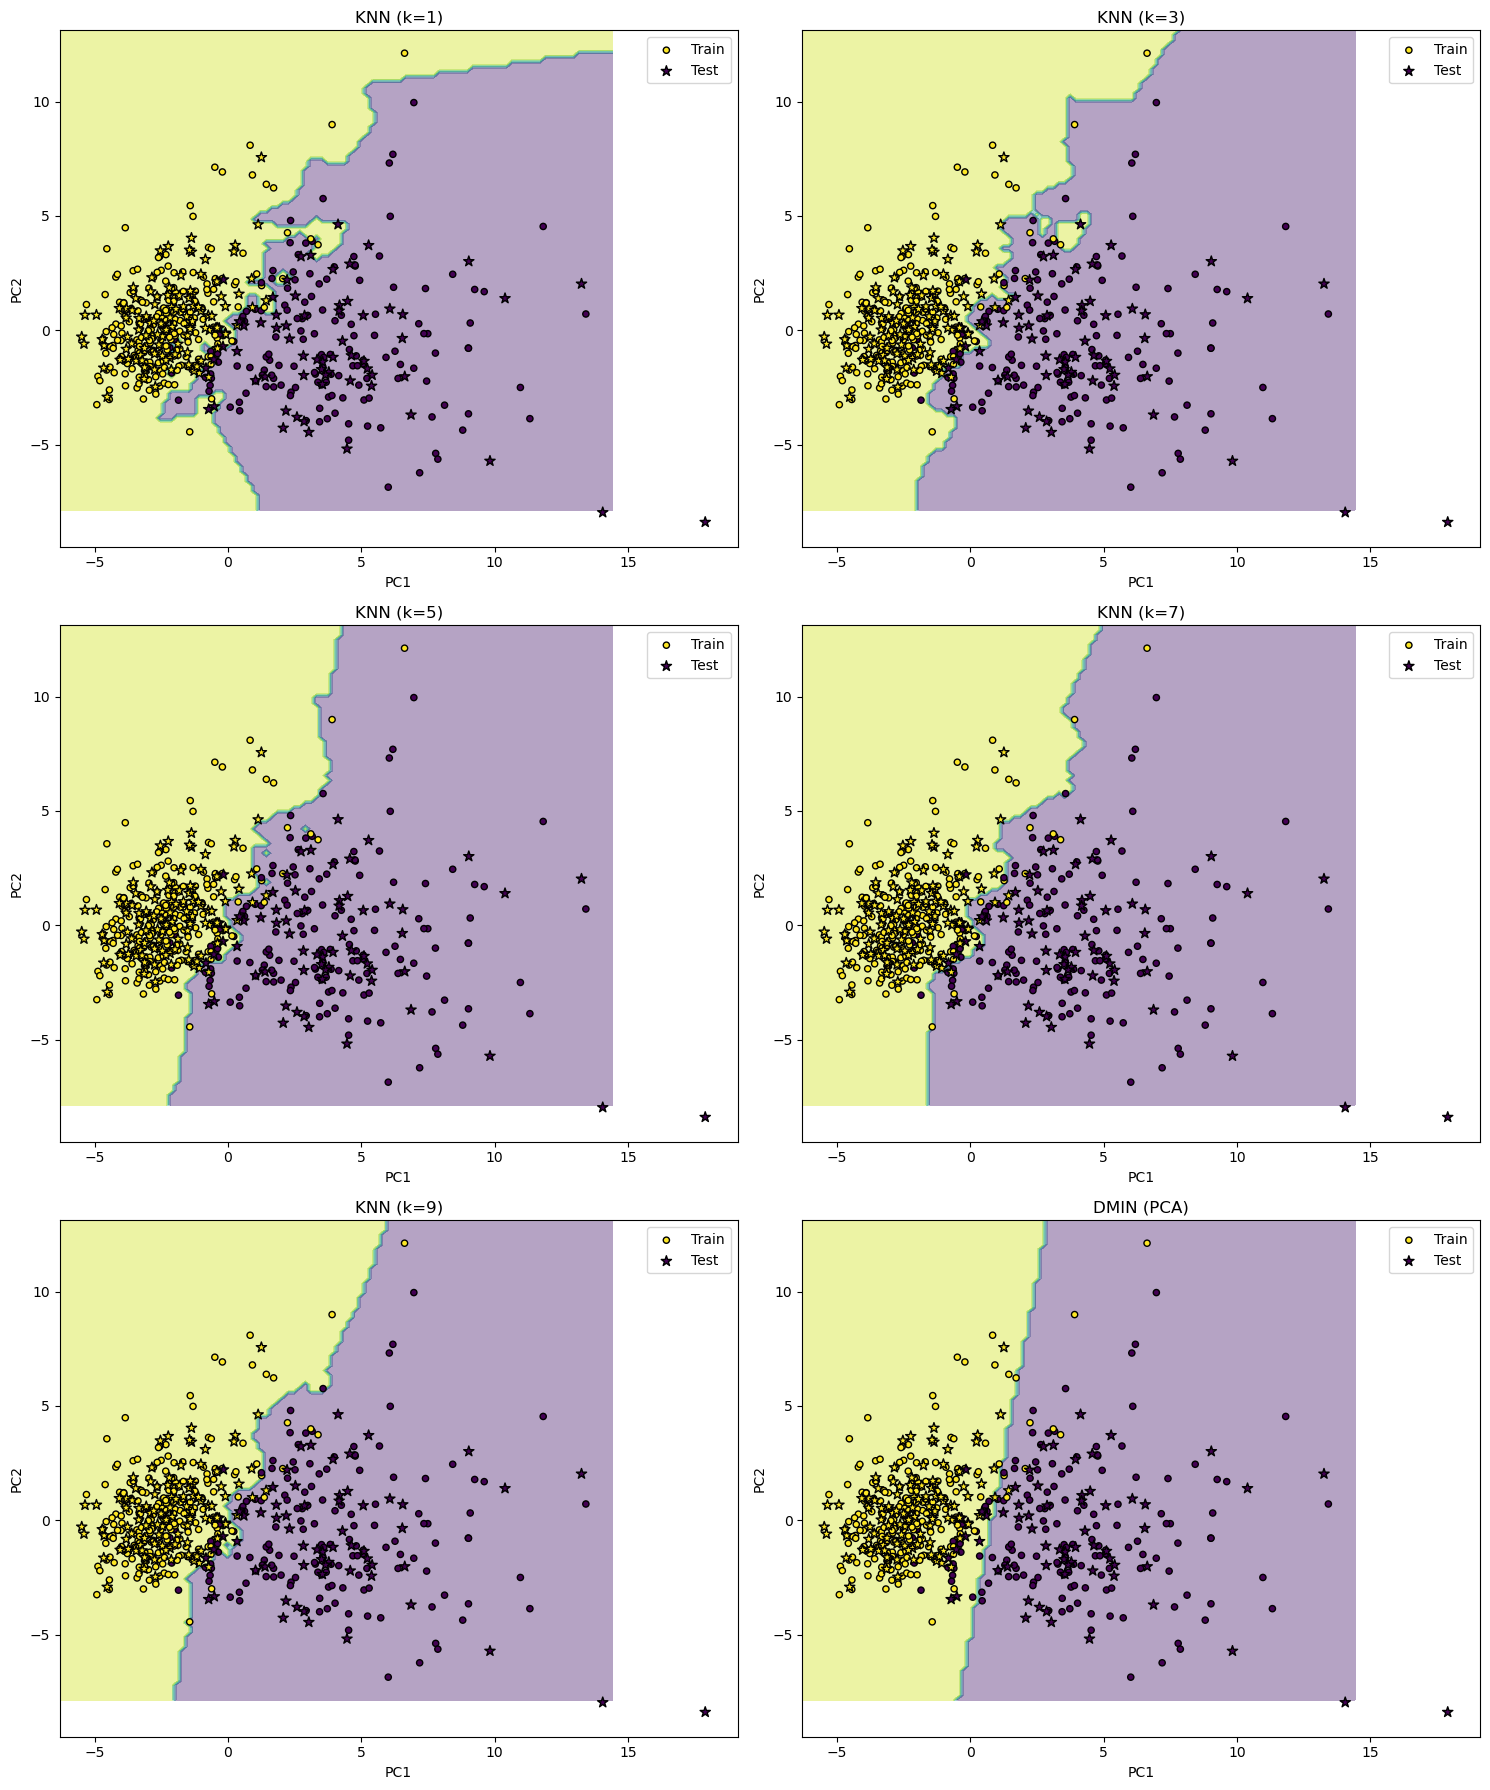

In [10]:
# PCA solo para visualización (2 componentes)
pca_vis = PCA(n_components=2)
X_train_pca_vis = pca_vis.fit_transform(X_train_scaled)
X_test_pca_vis = pca_vis.transform(X_test_scaled)

# Entrenar modelos con solo 2 componentes
knn_pca_vis_models = []
for k in k_values:
    knn_pca_vis = KNeighborsClassifier(n_neighbors=k)
    knn_pca_vis.fit(X_train_pca_vis, y_train)
    knn_pca_vis_models.append(knn_pca_vis)

# Entrenar DMIN con PCA para visualización
dmin_pca_vis = DMINClassifier()
dmin_pca_vis.fit(X_train_pca_vis, y_train)
y_pred_dmin_pca_vis = dmin_pca_vis.predict(X_test_pca_vis)

# Visualización
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()
for idx, model in enumerate(knn_pca_vis_models):
    plot_decision_boundaries(
        model,
        X_train_pca_vis,
        y_train,
        f"KNN (k={k_values[idx]})",
        axes[idx],
        X_test=X_test_pca_vis,
        y_test=y_test
    )
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')

plot_decision_boundaries(dmin_pca_vis, X_train_pca_vis, y_train, 'DMIN (PCA)', axes[5], X_test=X_test_pca_vis, y_test=y_test)
axes[5].set_xlabel('PC1')
axes[5].set_ylabel('PC2')

plt.tight_layout()
plt.show()


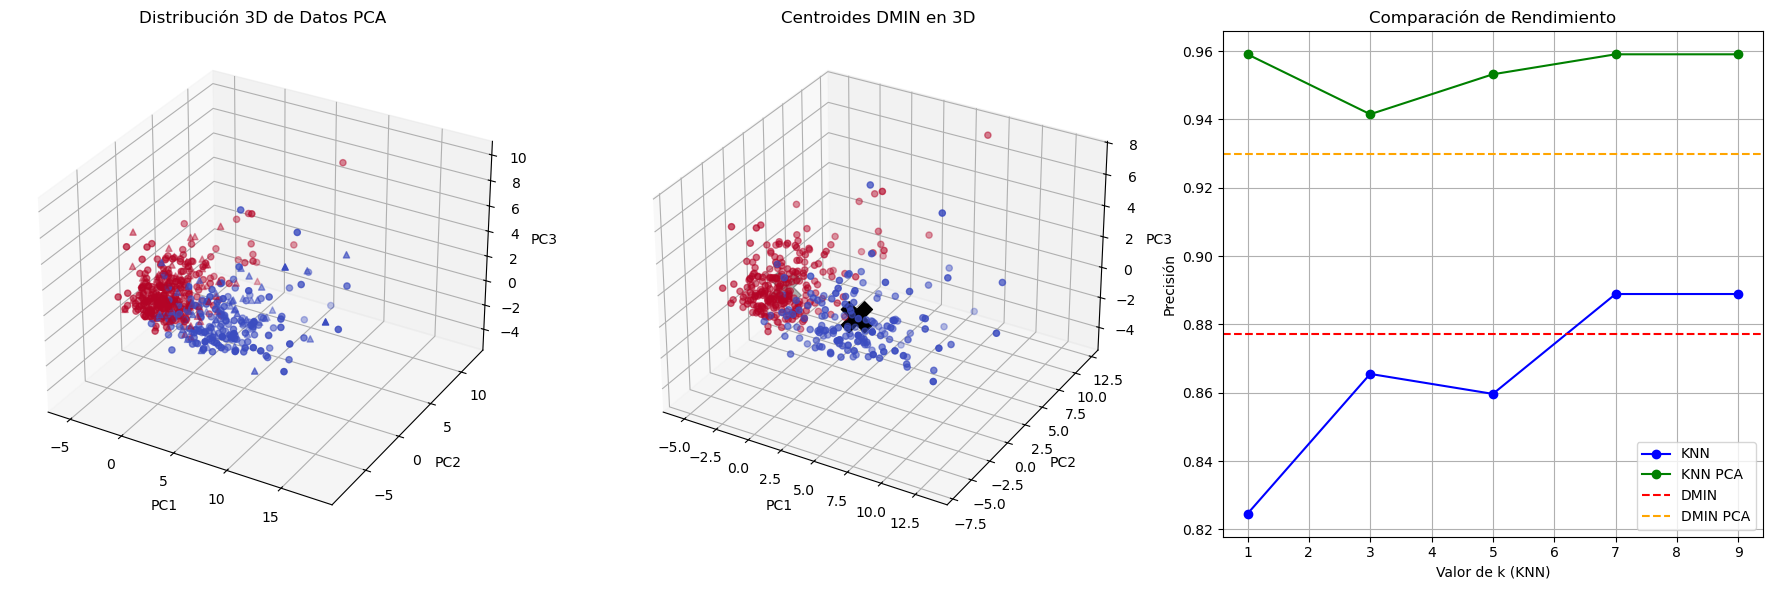

In [11]:
# Visualizacion 3D
fig = plt.figure(figsize=(18, 6))

# KNN 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='coolwarm', label='Entrenamiento')
ax1.scatter(X_test_pca[:, 0], X_test_pca[:, 1], X_test_pca[:, 2], c=y_test, marker='^', cmap='coolwarm', label='Prueba')
ax1.set_title('Distribución 3D de Datos PCA')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# DMIN 3D
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='coolwarm')
ax2.scatter(np.array(dmin_pca.centroids)[:, 0],
            np.array(dmin_pca.centroids)[:, 1],
            [0, 0], s=500, marker='X', color='black')
ax2.set_title('Centroides DMIN en 3D')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

# Comparación de precisión
ax3 = fig.add_subplot(133)
ax3.plot(k_values, knn_accuracies, 'bo-', label='KNN')
ax3.plot(k_values, knn_pca_accuracies, 'go-', label='KNN PCA')
ax3.axhline(acc_dmin, color='r', linestyle='--', label='DMIN')
ax3.axhline(acc_dmin_pca, color='orange', linestyle='--', label='DMIN PCA')
ax3.set_xlabel('Valor de k (KNN)')
ax3.set_ylabel('Precisión')
ax3.set_title('Comparación de Rendimiento')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

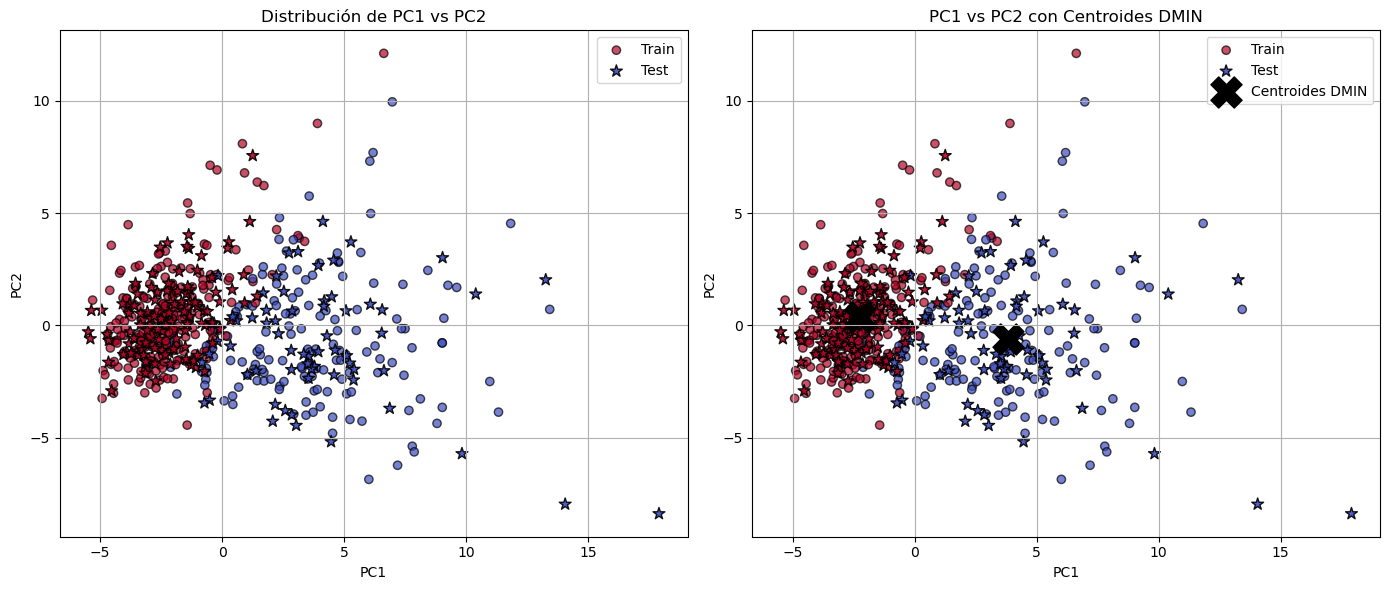

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot of PC1 vs PC2 (train and test set)
axes[0].scatter(X_train_pca_vis[:, 0], X_train_pca_vis[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', alpha=0.7, marker='o', label='Train')
axes[0].scatter(X_test_pca_vis[:, 0], X_test_pca_vis[:, 1], c=y_test, cmap='coolwarm', edgecolor='k', alpha=0.9, marker='*', s=80, label='Test')
axes[0].set_title('Distribución de PC1 vs PC2')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# Scatter plot with DMIN centroids
axes[1].scatter(X_train_pca_vis[:, 0], X_train_pca_vis[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', alpha=0.7, marker='o', label='Train')
axes[1].scatter(X_test_pca_vis[:, 0], X_test_pca_vis[:, 1], c=y_test, cmap='coolwarm', edgecolor='k', alpha=0.9, marker='*', s=80, label='Test')
centroids = np.array(dmin_pca_vis.centroids)
axes[1].scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=500, label='Centroides DMIN')
axes[1].set_title('PC1 vs PC2 con Centroides DMIN')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

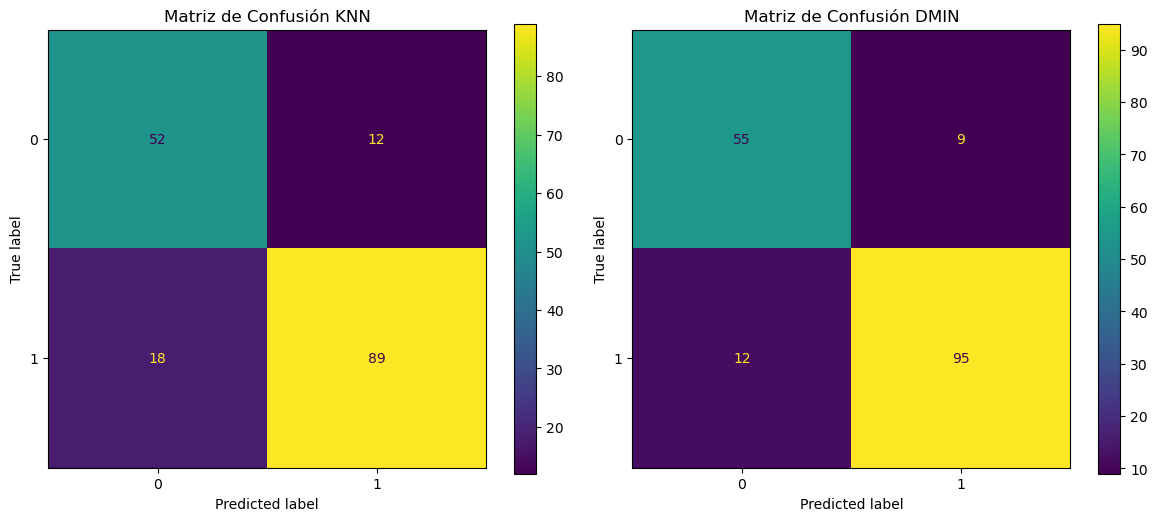


Resultados Finales:
Mejor KNN con k=1
Exactitud = 0.8889
DMIN: Exactitud = 0.9298
Varianza explicada por componentes PCA: [0.45156229 0.19628669 0.08897898]


In [15]:
knn_best = knn_models[np.argmax(knn_pca_accuracies)]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(knn_best, X_test[:, :2], y_test, ax=ax[0])
ax[0].set_title('Matriz de Confusión KNN')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dmin, ax=ax[1])
ax[1].set_title('Matriz de Confusión DMIN')

plt.tight_layout()
plt.show()

print(f"\n{'='*40}\nResultados Finales:\n{'='*40}")
print(f"Mejor KNN con k={k_values[np.argmax(knn_pca_accuracies)]}")
print(f"Exactitud = {max(knn_accuracies):.4f}")
print(f"DMIN: Exactitud = {acc_dmin_pca:.4f}")
print(f"Varianza explicada por componentes PCA: {pca.explained_variance_ratio_[:3]}")